# Superstore Sales Analysis
**Analyst:** Kushagra Yadav

**Date:** July 2026

**Dataset:** 51,290 orders | 2011-2014 | Superstore Orders

## Objective
To analyze superstore sales data and uncover key insights around regional performance, product profitability, and the impact of discounting on overall business health.

## Tools Used
Python (Pandas, Numpy, Matplotlib, Seaborn) | SQL (SQLite) | Power BI | Git

### 1. Importing the Libraries and Loading the dataset

In [68]:
import pandas as pd
import numpy as np

In [70]:
df = pd.read_csv("SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


-------------------------------------
### 2. Basic Structure check

In [73]:
df.shape

(51290, 21)

In [75]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [79]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           48660 non-null  float64
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

---------------------------------------------
### 3. Check for Null values

In [82]:
df.isnull().sum()

order_id             0
order_date           0
ship_date            0
ship_mode            0
customer_name        0
segment              0
state                0
country              0
market               0
region               0
product_id           0
category             0
sub_category         0
product_name         0
sales             2630
quantity             0
discount             0
profit               0
shipping_cost        0
order_priority       0
year                 0
dtype: int64

In [84]:
df[df['sales'].isnull()][['sales', 'product_name','category']].head(10)

,sales,product_name,category
27,NaN,"Dania Classic Bookcase, Pine",Furniture
43,NaN,"Hoover Stove, Black",Office Supplies
58,NaN,Global Deluxe High-Back Manager's Chair,Furniture
83,NaN,"Ikea Classic Bookcase, Pine",Furniture
84,NaN,"Panasonic Inkjet, White",Technology
100,NaN,"Nokia Smart Phone, with Caller ID",Technology
125,NaN,"SAFCO Executive Leather Armchair, Red",Furniture
126,NaN,"Smead Lockers, Blue",Office Supplies
163,NaN,"HP Fax Machine, Laser",Technology
173,NaN,Tennsco 6- and 18-Compartment Lockers,Office Supplies


In [86]:
total_rows = len(df)
null_sales = df['sales'].isnull().sum()
percentage = (null_sales / total_rows) * 100
print(f"Total Rows: {total_rows}")
print(f"Null Sales Rows: {null_sales}")
print(f"Percentage Missing: {percentage:.2f}%")

Total Rows: 51290
Null Sales Rows: 2630
Percentage Missing: 5.13%


In [88]:
# Filling the missing sales with median sales of that category
# Median is better than mean because it's not affected by extreme values
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'] = df.groupby('category')['sales'].transform(
    lambda x: x.fillna(x.median())
)

# Verifying nulls are gone
print("Remaining Nulls in Sales:", df['sales'].isnull().sum())
print("Sales dtype:", df['sales'].dtype)

Remaining Nulls in Sales: 0
Sales dtype: float64


#### Handling Missing Sales Values
- 2,630 rows had missing sales values (5.13% of data)
- Fix: Filled with category-level median
- Reason: Category median preserves realistic sales ranges per product type

---------------------------------------------------------
### 4. Check for Duplicate values

In [24]:
df.duplicated().sum()

0

#### No Duplicate Values in the dataset

-----------------------------------------
### 5. Fixing Data types

In [28]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst = True, format = 'mixed')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst = True, format = 'mixed')

In [30]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

#### *Earlier the order_date and ship_date attribute has the object data type which is now corrected to datetime64.*

------------------------------------------------
### 6. Check for Outliers in sales and profit

In [34]:
df[['sales', 'profit', 'discount', 'quantity']].describe()

,sales,profit,discount,quantity
count,51290.000000,51290.000000,51290.000000,51290.000000
mean,161.733242,28.641740,0.142908,3.476545
std,196.492922,174.424113,0.212280,2.278766
min,0.000000,-6599.978000,0.000000,1.000000
25%,31.000000,0.000000,0.000000,2.000000
50%,82.000000,9.240000,0.000000,3.000000
75%,218.000000,36.810000,0.200000,5.000000
max,999.000000,8399.976000,0.850000,14.000000


-------------------------------------
### 7. Check unique values in key categorical columns

In [37]:
df['region'].unique()

array(['Africa', 'Oceania', 'EMEA', 'North', 'Canada', 'Southeast Asia',
       'Central', 'South', 'Caribbean', 'North Asia', 'East', 'West',
       'Central Asia'], dtype=object)

In [39]:
df['category'].unique()

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [41]:
df['segment'].unique()

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

In [43]:
df['ship_mode'].unique()

array(['Standard Class', 'Second Class', 'Same Day', 'First Class'],
      dtype=object)

### Saving the cleaned dataset as CSV

In [46]:
df.to_csv('SuperStore_Cleaned.csv', index = False)

----------------------------------------------------------------------------------------------

# Real Business SQL queries
---------------------------------------

## Import Libraries & Load the cleaned dataset

In [51]:
import pandas as pd
import sqlite3

df = pd.read_csv("SuperStore_Cleaned.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


In [53]:
print(df.shape)

(51290, 21)


---
# SQL Business Queries

### Creating SQLite database

In [56]:
# Creating a database file called SuperStore.db
conn = sqlite3.connect("SuperStore.db")

# Loading dataframe into SQL table called "sales"
df.to_sql("sales", conn, if_exists = "replace", index = False)
print("Data loaded into SQLite Successfully!")

Data loaded into SQLite Successfully!


---------------------------------------------------
### 1. Total sales and profit by region

In [59]:
query1 = """
SELECT region,
       ROUND(SUM(sales), 2) AS total_sales,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(AVG(profit), 2) AS avg_profit
FROM sales
GROUP BY region
ORDER BY total_sales DESC;
"""

result1 = pd.read_sql(query1, conn)
result1

,region,total_sales,total_profit,avg_profit
0,Central,1906844.0,311403.98,28.01
1,South,1081654.0,140355.77,21.12
2,North,837931.0,194597.95,40.67
3,Oceania,669743.0,121666.64,34.89
4,EMEA,600132.0,43897.97,8.73
5,Southeast Asia,567047.0,17852.33,5.71
6,Africa,562838.0,88871.63,19.37
7,North Asia,494339.0,165578.42,70.82
8,West,450993.0,108418.45,33.85
9,Central Asia,422995.0,132480.19,64.69


### Business ques.1) Which region makes the most money and which is the least profitable?
### Ans.1) 
- The Central region leads in total sales `$1,906,844` but needs deeper margin analysis.
- Canada shows the lowest profit `$17,817` — likely due to high shipping costs and small customer base in that market.

Recommendation: Focus growth efforts on high-margin regions and investigate why Canada underperforms despite being a developed market.

--------------------------------------------------------------------
### 2. Top 10 Products by profit

In [63]:
query2 = """
SELECT product_name, category,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(sales), 2) AS total_sales,
       COUNT(order_id) AS total_orders
FROM sales
GROUP BY product_name
ORDER BY total_profit DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,product_name,category,total_profit,total_sales,total_orders
0,Canon imageCLASS 2200 Advanced Copier,Technology,25199.93,1125.0,5
1,"Cisco Smart Phone, Full Size",Technology,17238.52,13295.0,38
2,"Motorola Smart Phone, Full Size",Technology,17027.11,14107.0,38
3,"Hoover Stove, Red",Office Supplies,11807.97,4043.0,15
4,"Sauder Classic Bookcase, Traditional",Furniture,10672.07,11077.0,29
5,"Harbour Creations Executive Leather Armchair, ...",Furniture,10427.33,14627.0,39
6,"Nokia Smart Phone, Full Size",Technology,9938.20,16437.0,47
7,"Cisco Smart Phone, with Caller ID",Technology,9786.64,10925.0,27
8,"Nokia Smart Phone, with Caller ID",Technology,9465.33,6801.0,24
9,"Belkin Router, USB",Technology,8955.02,12289.0,32


### Business ques.2) Which products makes the most profit?
### Ans.2)
- Canon imageCLASS 2200 Advanced Copier is the star product with `$25,199` profit.
- The top 10 profitable products span Technology, Furniture and Office Supplies categories - showing profit drivers aren't limited to one department.

---------------------------------------------------------
### 3. Bottom 10 products by profit(loss makers)

In [87]:
query3 = """
SELECT product_name,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_profit ASC
LIMIT 10;
"""
result3 = pd.read_sql(query3, conn)
result3

,product_name,total_profit,total_sales
0,Cubify CubeX 3D Printer Double Head Print,-8879.97,675.0
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.97,900.0
2,"Motorola Smart Phone, Cordless",-4447.04,7822.0
3,Cubify CubeX 3D Printer Triple Head Print,-3839.99,225.0
4,"Bevis Round Table, Adjustable Height",-3649.89,1068.0
5,"Bevis Computer Table, Fully Assembled",-3509.56,7486.0
6,"Rogers Lockers, Blue",-2893.49,16854.0
7,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.12,1087.0
8,"Bevis Wood Table, with Bottom Storage",-2782.59,4337.0
9,"Lesro Training Table, Rectangular",-2581.28,2712.0


### Business ques.3) Which products are actually losing the company's money?
### Ans.3)
Top 10 loss-making products lost the company significant profit despite generating sales.
- Rogers Lockers Blue is most alarming — `$16,854` in sales but still `$2,893` in losses, meaning every sale actually costs the business money.
- Cubify CubeX 3D Printer lost `$8,879` on just `$675` in sales — a critical failure.

Recommendation: Discontinue or reprice these products immediately. Review discount and shipping cost structure for Furniture and Technology items.

---------------------------------------------------------------------------------
### 4. Sales by profit by category and sub-category

In [91]:
query4 = """
SELECT category,
       sub_category,
       ROUND(SUM(sales), 2) AS total_sales,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(profit)/SUM(sales)*100, 2) AS profit_margin_pct
FROM sales
GROUP BY category, sub_category
ORDER BY profit_margin_pct DESC;
"""
result4 = pd.read_sql(query4, conn)
result4

,category,sub_category,total_sales,total_profit,profit_margin_pct
0,Office Supplies,Appliances,392350.0,141680.59,36.11
1,Technology,Copiers,875635.0,258567.55,29.53
2,Office Supplies,Paper,244307.0,59207.68,24.23
3,Technology,Phones,962093.0,216717.01,22.53
4,Technology,Accessories,596829.0,129626.31,21.72
5,Office Supplies,Binders,348110.0,72449.85,20.81
6,Office Supplies,Labels,73433.0,15010.51,20.44
7,Furniture,Bookcases,883325.0,161924.42,18.33
8,Office Supplies,Envelopes,170926.0,29601.12,17.32
9,Office Supplies,Art,371095.0,57953.91,15.62


### Business ques.4) Which category/sub-category has the best profit margin?
### Ans.4) 
Office Supplies - Appliances has the highest profit margin at 36.11% — meaning for every `$100` sold, `$36.11` is pure profit.
> *(Profit margin = how many cents of every sales dollar the company actually keeps after costs. A 36% margin means `$36` of profit for every `$100` sold — far better than a category like Furniture, which barely breaks even.)*
- This makes it the most efficient category in the business.

Recommendation: Prioritize Appliances in promotions and upselling strategies since they generate the highest return per sale.

-------------------------------------------------------
### 5. Impact of discount on profit

In [95]:
query5 = """
SELECT CASE
       WHEN discount = 0 THEN 'No Discount'
       WHEN discount <= 0.2 THEN 'Low (0-20%)'
       WHEN discount <= 0.4 THEN 'Medium (20-40%)'
       ELSE 'High (40%+)'

       END AS discount_range,
       COUNT(*) AS total_orders,
       ROUND(AVG(profit), 2) AS avg_profit,
       ROUND(SUM(profit), 2) AS total_profit
FROM sales
GROUP BY discount_range
ORDER BY avg_profit DESC;
"""
result5 = pd.read_sql(query5, conn)
result5

,discount_range,total_orders,avg_profit,total_profit
0,No Discount,29009,61.04,1770695.27
1,Low (0-20%),10953,46.84,513021.63
2,Medium (20-40%),4367,-42.88,-187271.06
3,High (40%+),6961,-90.13,-627411.02


### Business ques.5) Does heavy discounting hurt profit?
### Ans.5) 
- No/Low discount (0-20%) → orders are profitable
- Medium discount (20-40%) → average profit drops to `-$42.88` (loss per order)
- High discount (40%+) → average profit of `-$90.13`, total loss of `$627,411`

The company is LOSING `$627,411` purely because of heavy discounting.

Recommendation: Cap maximum discount at 20% across all products. This single change could recover over `$600,000` in lost profit.

------------------------------------
### 6. Yearly Sales trend

In [80]:
query6 = """
SELECT
     strftime('%Y', order_date) AS year,
     ROUND(SUM(sales), 2) AS total_sales,
     ROUND(SUM(profit), 2) AS total_profit,
     COUNT(DISTINCT order_id) AS total_orders
FROM sales
GROUP BY year
ORDER BY year ASC;
"""
result6 = pd.read_sql(query6, conn)
result6

,year,total_sales,total_profit,total_orders
0,2011,1460762.0,248940.81,4440
1,2012,1780760.0,307415.28,5343
2,2013,2231212.0,408512.76,6721
3,2014,2822564.0,504165.97,8531


### Business ques.6) Is the business growing year over year? 
### Ans.6)
The business shows consistent growth from 2011 to 2014 in both sales and orders. This confirms the company is scaling successfully.
- However, growth in sales does not always mean growth in profit — as seen in Insight 5, heavy discounting is offsetting revenue gains.

Recommendation: Maintain sales growth momentum but fix discount policy to ensure profit grows proportionally with sales.

----------------------------------------------------
## Close the database connection

In [84]:
conn.close()
print("Connection closed.")

Connection closed.


---

# Exploratory Data Analysis & Visualizations
* Based on the SQL analysis above, the following charts visually confirm and communicate our key business findings.
---

## Importing libraries and loading cleaned dataset

In [89]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcdefaults()
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Loading data
df = pd.read_csv("SuperStore_Cleaned.csv")
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['shipping_cost'] = pd.to_numeric(df['shipping_cost'], errors='coerce')
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, format='mixed')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True, format='mixed')

print("Data loaded:", df.shape)
df.head()

Data loaded: (51290, 21)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


---------------------------------------------------------------------
### Visualization 1:- Sales by Region

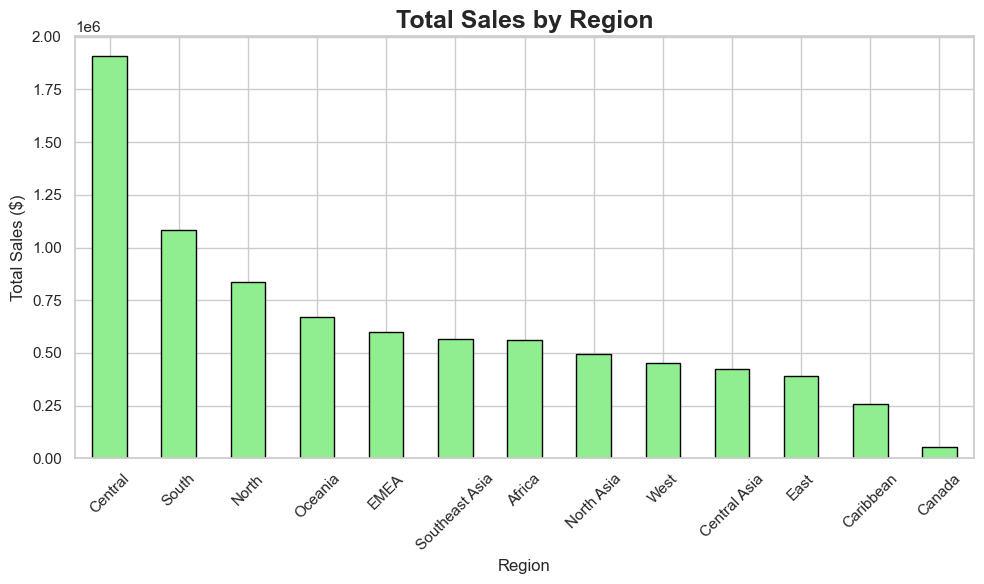

In [91]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Total Sales by Region', fontsize=18, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('1_sales_by_region.png')
plt.show()

#### Business Insight — Sales by Region
**What the data shows:** Central region leads total sales at `$1.9M`, followed by South (`$1.08M`) and North (`$0.84M`)

**Why it matters:** High sales volume doesn't guarantee profitability — a region can sell more but earn less if discounts are high

**Action:** Cross-reference sales leaders with profit data before increasing marketing spend in any region

---
### Visualization 2:- Profit by Region

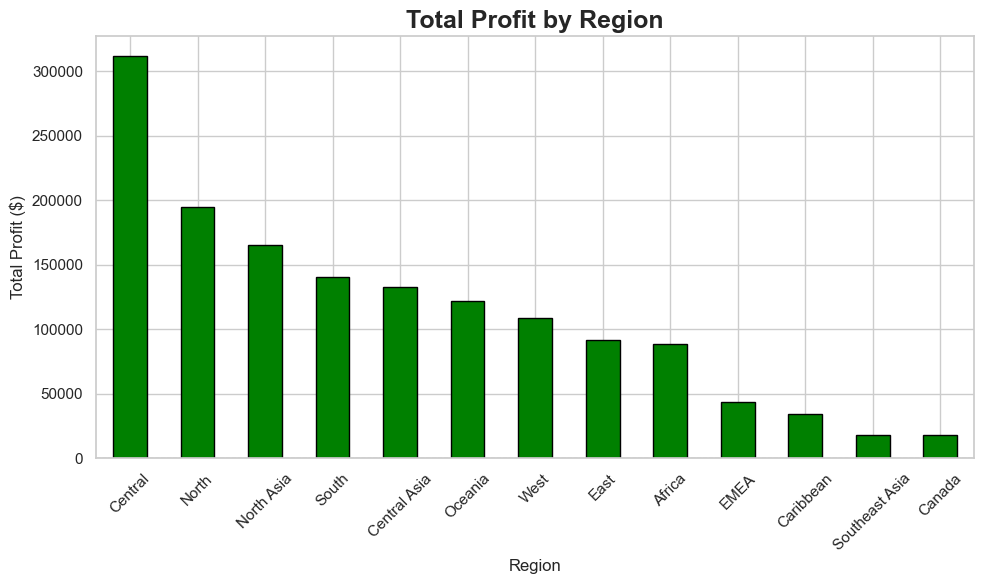

In [96]:
region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False)

colors = ['green' if x > 0 else 'red' for x in region_profit]
region_profit.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Total Profit by Region', fontsize=18, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('2_profit_by_region.png')
plt.show()

#### Business Insight — Profit by Region
**What the data shows:** Canada generates the lowest profit despite being a separate market segment  
**Why it matters:** Resources invested in Canada are generating minimal returns — this is a strategic blind spot  
**Action:** Conduct a cost audit for Canada operations — either reduce costs, increase prices, or reconsider market presence

---
### Visualization 3:- Yearly Sales Trend

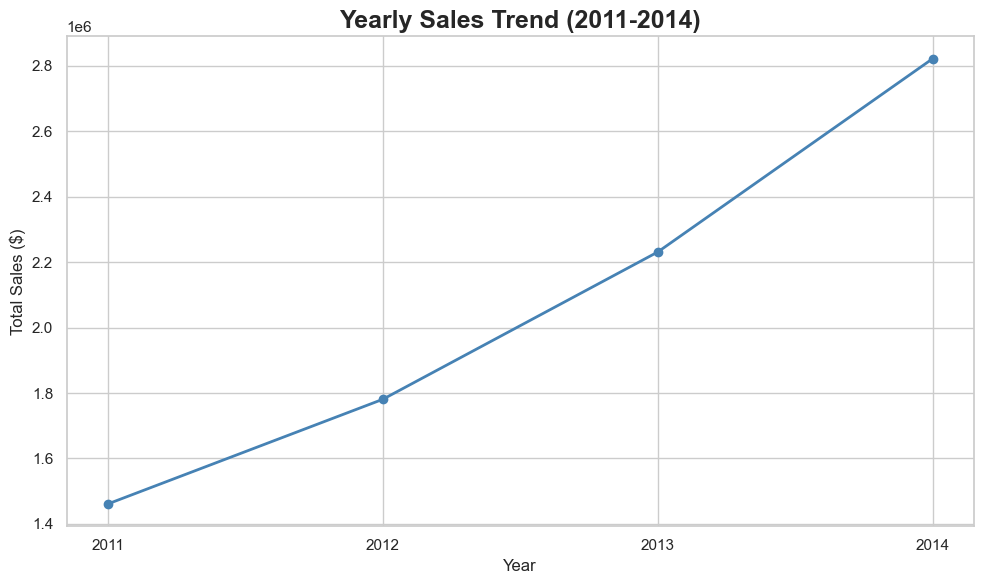

In [100]:
df['year'] = df['order_date'].dt.year
yearly_sales = df.groupby('year')['sales'].sum()

yearly_sales.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Yearly Sales Trend (2011-2014)', fontsize=18, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.xticks([2011, 2012, 2013, 2014])
plt.tight_layout()
plt.savefig('3_yearly_trend.png')
plt.show()

#### Business Insight — Yearly Growth Trend
**What the data shows:** Consistent year-over-year revenue growth from 2011 to 2014  
**Why it matters:** The business is expanding — but growing revenue alone is misleading if profit isn't growing at the same rate  
**Action:** Track profit growth alongside revenue growth — if profit growth is slower, the discount policy is the likely cause

---
### Visualization 4:- Sales VS Profit by Category

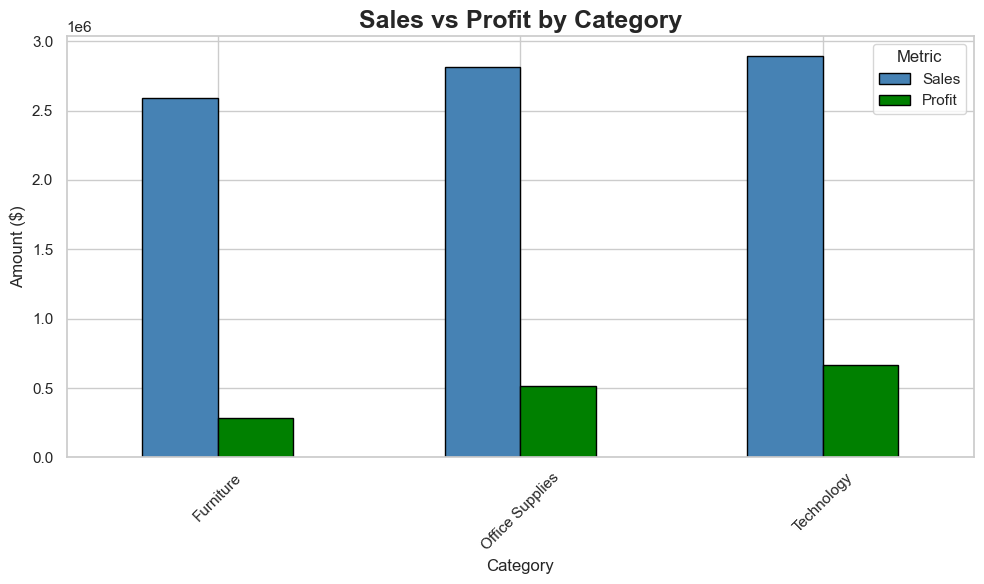

In [104]:
category_sales = df.groupby('category')['sales'].sum()
category_profit = df.groupby('category')['profit'].sum()

category_df = pd.DataFrame({'Sales': category_sales, 'Profit': category_profit})
category_df.plot(kind='bar', color=['steelblue', 'green'], edgecolor='black')

plt.title('Sales vs Profit by Category', fontsize=18, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('4_category.png')
plt.show()

#### Business Insight — Category Performance
**What the data shows:** Technology has highest sales but Office Supplies delivers the best profit margin. Furniture has strong sales but the weakest profit  
**Why it matters:** Furniture is consuming sales resources while delivering poor returns — a classic high-effort, low-reward scenario  
**Action:** Prioritize Office Supplies (especially Appliances at 36.11% margin) in marketing. Audit Furniture pricing and discount strategy immediately

----
### Visualization 5:- Discount VS Profit

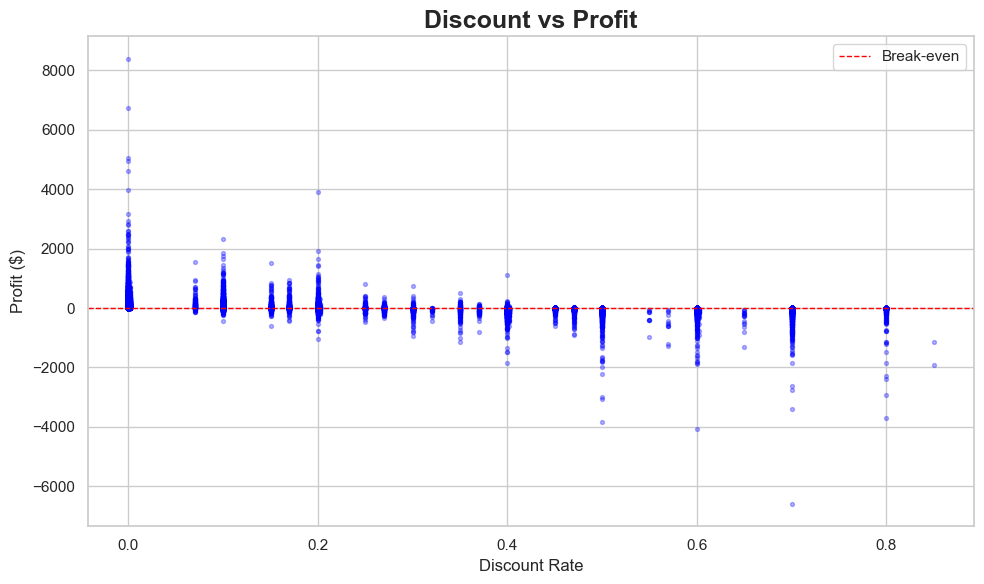

In [108]:
plt.scatter(df['discount'], df['profit'], alpha=0.3, color='blue', s=8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break-even')
plt.title('Discount vs Profit', fontsize=18, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('5_discount_profit.png')
plt.show()

#### Business Insight — The Discount Problem (Most Critical Finding)
**What the data shows:** Every order with a discount above 20% falls below the break-even line into loss territory. High discounts (40%+) caused `$627,411` in total losses - over 40% of the company's entire profit, wiped out by discounting alone.

> (Break-even line = The point where an order stops making money and starts losing it.)

**Why it matters:** The company is actively losing money on heavily discounted orders — discounting is not driving enough volume to make up for the profit it destroys.

**Action:** Cap all discounts at 20% company-wide. This single policy change could recover $600K+ in annual profit without requiring any increase in sales volume.

---
### Visualization 6:- Top 10 Profitable Products

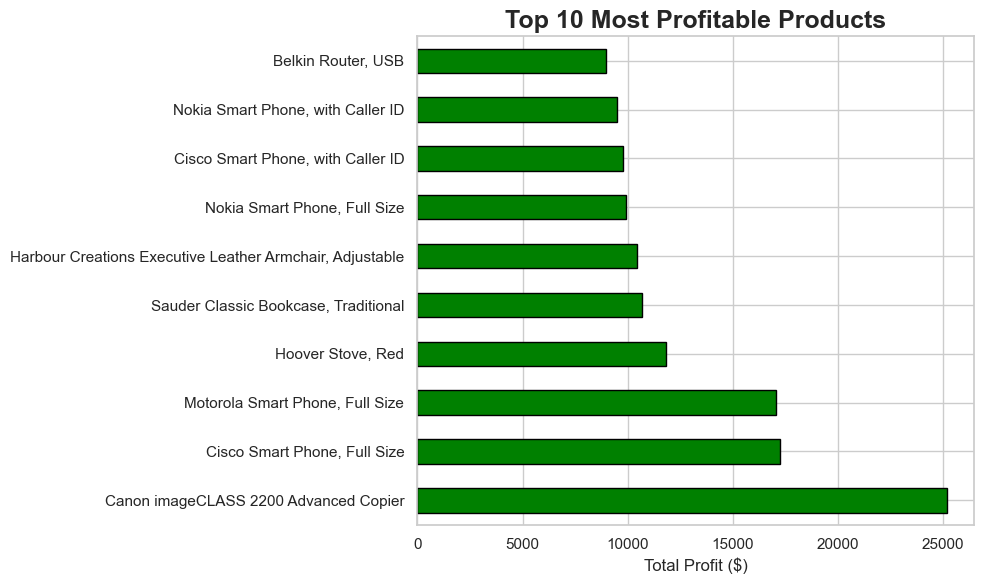

In [112]:
top10 = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)

top10.plot(kind='barh', color='green', edgecolor='black')
plt.title('Top 10 Most Profitable Products', fontsize=18, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('6_top10_products.png')
plt.show()

#### Business Insight — Star Products
**What the data shows:** Canon imageCLASS 2200 Advanced Copier leads with `$25,199` in profit. Technology products dominate the top 10 list  
**Why it matters:** A small group of products is generating a disproportionate share of total profit - the classic 80/20 rule in action  
**Action:** Increase inventory, visibility, and marketing spend on top 10 profit drivers. Protect these products from heavy discounting - they don't need it to sell.

---
### Visualization 7:- Correlation Heatmap

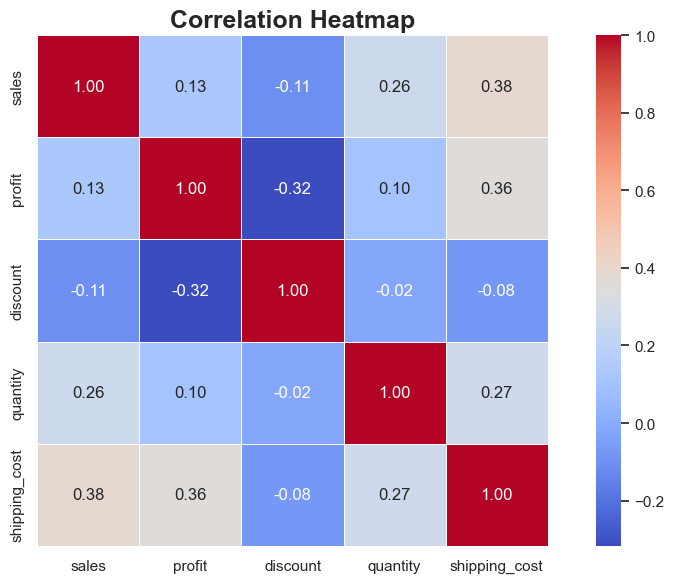

In [116]:
numeric_cols = df[['sales', 'profit', 'discount', 'quantity', 'shipping_cost']]
correlation = numeric_cols.corr()

sns.heatmap(correlation, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square= True)
plt.title('Correlation Heatmap', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('7_heatmap.png')
plt.show()

#### Business Insight — Key Correlations
**What the data shows:** As discounts go up, profit reliably goes down - this pattern holds consistently across the entire dataset (correlation: -0.32, a moderate relationship). Meanwhile, selling more doesn't move profit up much at all - sales volume and profit are only weakly connected. 

**Why it matters:** This proves selling more doesn't automatically mean earning more - discount policy, not sales volume, is the real lever controlling profit.   

**Action:** Stop measuring sales team performance on revenue alone. Introduce profit margin as a key performance metric alongside sales volume.

---
## FINAL SUMMARY — KEY BUSINESS INSIGHTS
---

### 1. Regional Performance
- Central region leads in total sales (`$1.9M`) but Canada is the least profitable market
- High sales volume in a region does not guarantee profitability
- **Action:** Audit Canada operations and cross-check all regional sales with profit data

### 2. Product Performance
- Canon imageCLASS 2200 Copier = star product (`$25,199` profit)
- Cubify CubeX 3D Printer = worst product (`-$8,879` loss on just `$675` in sales)
- **Action:** Discontinue or reprice loss-making products. Double marketing on top performers

### 3. Discount Problem — BIGGEST FINDING
- Discounts above 20% push every order into loss territory
- High discounts (40%+) caused `$627,411` in total losses - over 40% of the company's total profit.
- **Action:** Cap all discounts at 20% company-wide immediately

### 4. Category Insights
- Office Supplies -> Appliances = best profit margin at 36.11%
- Furniture = high sales but lowest profit - severely over-discounted
- **Action:** Prioritize Appliances in all marketing campaigns. Audit Furniture pricing

### 5. Business Growth
- Consistent YoY revenue growth 2011–2014 - business is expanding
- But profit growth is being eaten by poor discount management
- **Action:** Tie discount policy reform to growth strategy - more sales mean nothing if margins keep shrinking

---
#### This business is growing but leaving **`$600,000+`** - over 40% of its total profit - on the table every year through poor discount management. Fixing the discount policy alone - without needing any increase in sales - would dramatically improve profitability.
---